In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from pathlib import Path
import sys

# Add src to path
sys.path.append('src')
from generate_reconstructions import load_model
from compute_st_vae_anomaly import (
    compute_st_vae_reconstruction_and_anomaly,
    compute_st_vae_metrics_breakdown
)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# Create output directory
output_dir = Path("outputs/visualizations/st_vae")
output_dir.mkdir(parents=True, exist_ok=True)

print("Setup complete!")
print(f"Output directory: {output_dir}")

Setup complete!
Output directory: outputs\visualizations\st_vae


In [2]:
# Load ST-VAE model
print("Loading ST-VAE model...")
model = load_model('st_vae')
model.eval()
device = next(model.parameters()).device
print(f"Model loaded on {device}")
print(f"Beta: {model.beta}")

Loading ST-VAE model...
Loaded weights from C:\FYDP_CODE\Dataset\src\weights\st_vae_weights\best_model.pt
Model loaded on cuda:0
Beta: 0.5
Loaded weights from C:\FYDP_CODE\Dataset\src\weights\st_vae_weights\best_model.pt
Model loaded on cuda:0
Beta: 0.5


c:\FYDP_CODE\Dataset\src\generate_reconstructions.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path, map_location=DEVICE))


In [3]:
# Load samples from demo dataset
normal_dir = Path("data/demo_samples/normal")
abnormal_dir = Path("data/demo_samples/abnormal")

normal_files = sorted(list(normal_dir.glob("*.npy")))
abnormal_files = sorted(list(abnormal_dir.glob("*.npy")))

print(f"Available: {len(normal_files)} normal, {len(abnormal_files)} abnormal samples")

# Load single samples for detailed visualization
normal_sample = np.load(normal_files[0])  # For viz 1, 2, 4
abnormal_sample = np.load(abnormal_files[0])  # For viz 1, 2, 4

# Load 20 samples for histogram (viz 3)
normal_samples_20 = [np.load(f) for f in normal_files[:20]]
abnormal_samples_20 = [np.load(f) for f in abnormal_files[:20]]

print(f"\nLoaded samples:")
print(f"  Normal: {normal_files[0].name} - shape {normal_sample.shape}")
print(f"  Abnormal: {abnormal_files[0].name} - shape {abnormal_sample.shape}")
print(f"  Batch: 20 normal + 20 abnormal for KL histogram")

Available: 100 normal, 100 abnormal samples

Loaded samples:
  Normal: 00011_hr.npy - shape (12, 5000)
  Abnormal: 00103.npy - shape (5000, 12)
  Batch: 20 normal + 20 abnormal for KL histogram


## Helper Functions

In [4]:
def compute_kl_per_window(model, sig_np, window_size=1000, stride=500):
    """
    Compute KL divergence for each sliding window.
    Returns: kl_values (list), window_positions (list)
    """
    sig = torch.tensor(sig_np, dtype=torch.float32)
    
    # Ensure [12, T]
    if sig.shape[0] != 12:
        sig = sig.T
    
    T = sig.shape[1]
    sig_T = sig.T  # [T, 12]
    
    kl_values = []
    window_positions = []
    
    for start in range(0, T - window_size + 1, stride):
        window = sig_T[start:start+window_size].unsqueeze(0).to(device)  # [1, 1000, 12]
        
        with torch.no_grad():
            outputs = model(window)
            mu = outputs[2]  # [1, latent_dim] or [1, T, latent_dim]
            logvar = outputs[3]
            
            # Handle expanded tensors
            if mu.ndim == 3:
                mu = mu[:, 0, :]
                logvar = logvar[:, 0, :]
            
            # KL divergence
            kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            kl_values.append(kl.item())
            window_positions.append(start)
    
    return kl_values, window_positions


def normalize_shape(sig_np):
    """Ensure signal is [12, T]"""
    if sig_np.shape[0] != 12:
        return sig_np.T
    return sig_np


print("Helper functions defined!")

Helper functions defined!


## Visualization 1: Normal vs Abnormal Reconstruction

Shows original vs reconstructed signals with uncertainty bands and per-lead MSE

In [5]:
# Compute reconstructions
print("Computing reconstructions...")
recon_mean_n, recon_std_n, anomaly_map_n, score_n = \
    compute_st_vae_reconstruction_and_anomaly(model, normal_sample)

recon_mean_ab, recon_std_ab, anomaly_map_ab, score_ab = \
    compute_st_vae_reconstruction_and_anomaly(model, abnormal_sample)

print(f"Normal score: {score_n:.2f}")
print(f"Abnormal score: {score_ab:.2f}")

Computing reconstructions...
Normal score: 54364.17
Abnormal score: 77717.66
Normal score: 54364.17
Abnormal score: 77717.66


Saved: outputs\visualizations\st_vae\st_vae_normal_reconstruction.png


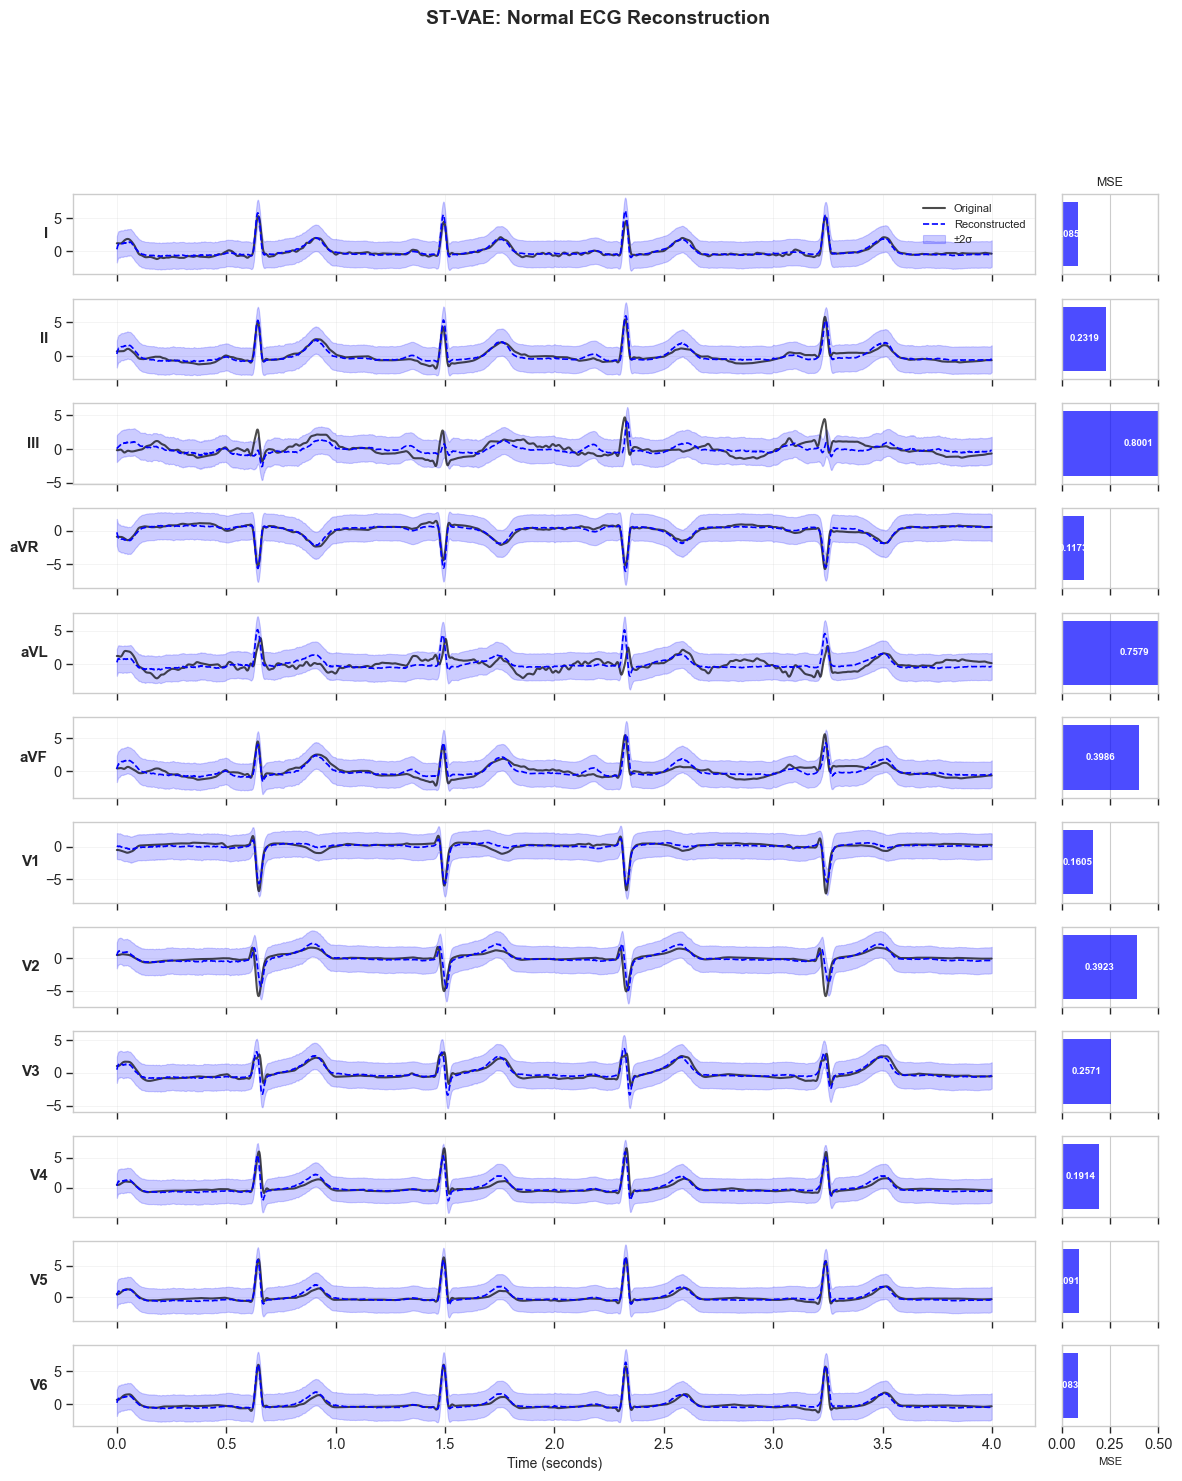

Saved: outputs\visualizations\st_vae\st_vae_abnormal_reconstruction.png


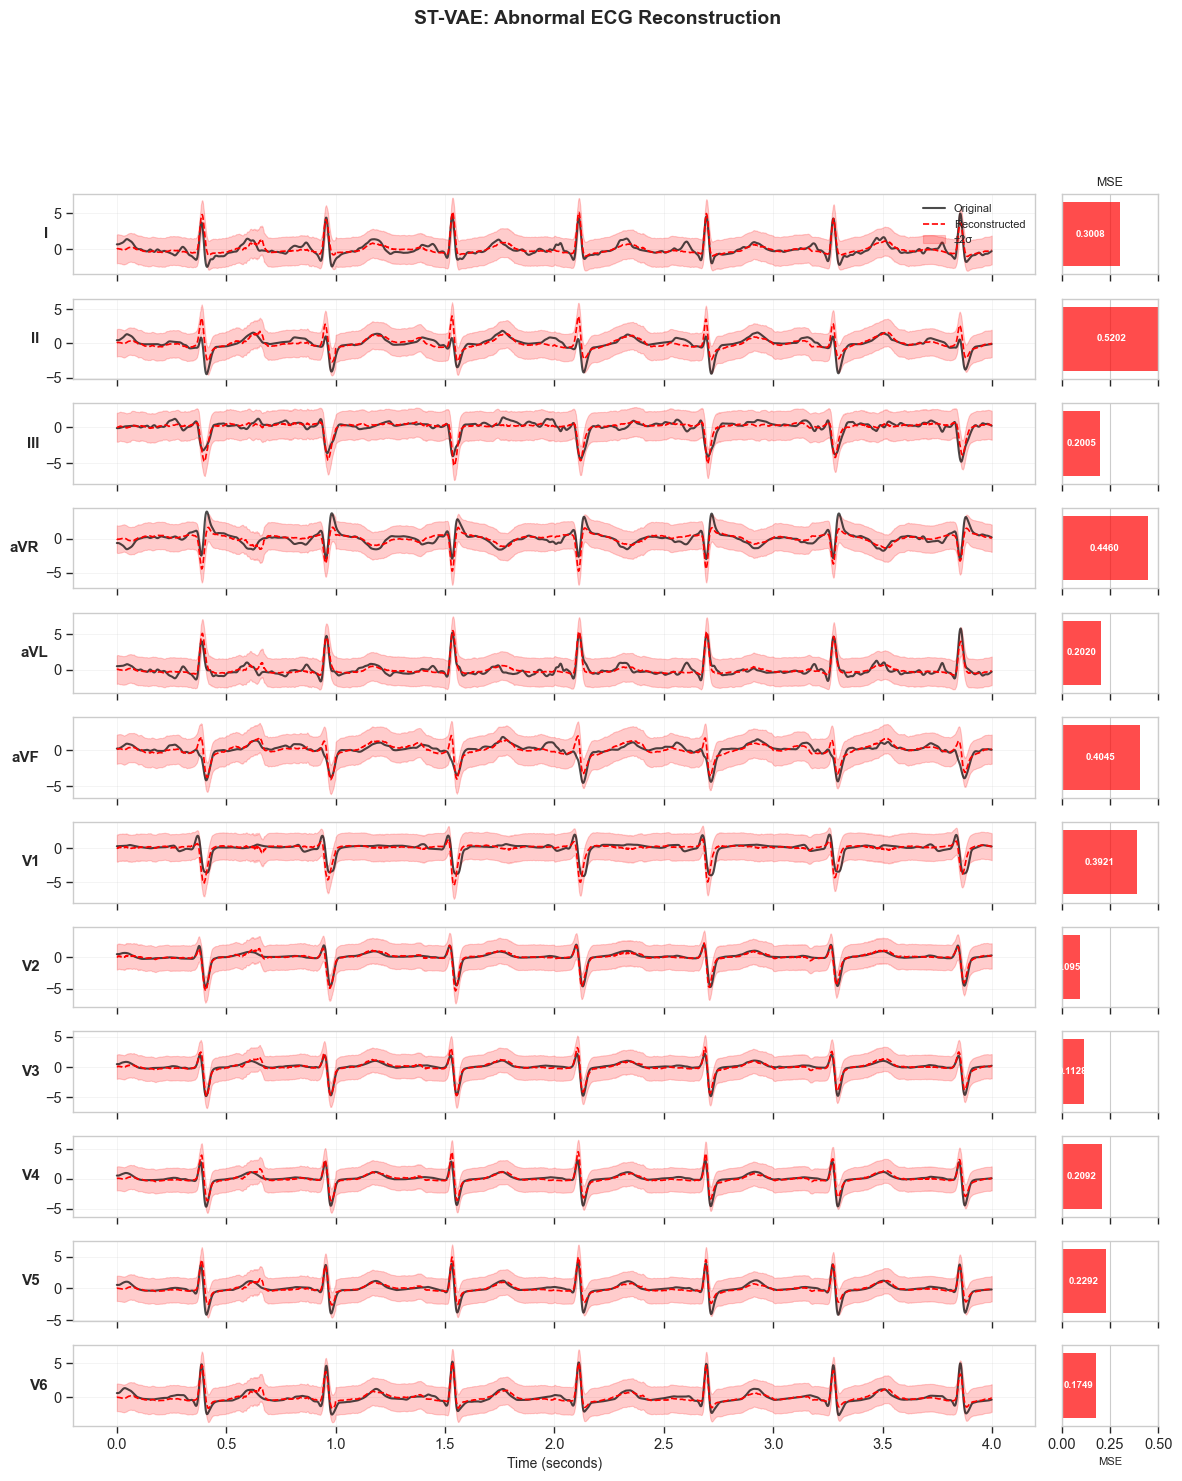

In [6]:
# Plot function for reconstruction
def plot_reconstruction(sig_np, recon_mean, recon_std, title, save_path, color='blue'):
    sig = normalize_shape(sig_np)
    lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    
    # Plot only first 2000 samples for clarity
    n_samples = 2000
    time = np.arange(n_samples) / 500  # Convert to seconds
    
    fig = plt.figure(figsize=(14, 16))
    gs = fig.add_gridspec(12, 2, width_ratios=[10, 1], hspace=0.3, wspace=0.05)
    
    for i in range(12):
        ax_main = fig.add_subplot(gs[i, 0])
        ax_mse = fig.add_subplot(gs[i, 1])
        
        # Main signal plot
        ax_main.plot(time, sig[i, :n_samples], 'k-', linewidth=1.5, label='Original', alpha=0.7)
        ax_main.plot(time, recon_mean[i, :n_samples], color=color, linewidth=1.2, 
                     label='Reconstructed', linestyle='--')
        
        # Uncertainty band (±2σ)
        ax_main.fill_between(time,
                             recon_mean[i, :n_samples] - 2*recon_std[i, :n_samples],
                             recon_mean[i, :n_samples] + 2*recon_std[i, :n_samples],
                             alpha=0.2, color=color, label='±2σ')
        
        ax_main.set_ylabel(lead_names[i], fontsize=11, fontweight='bold', rotation=0, 
                           ha='right', va='center')
        ax_main.grid(True, alpha=0.3, linewidth=0.5)
        
        if i == 0:
            ax_main.legend(loc='upper right', fontsize=8, framealpha=0.9)
        if i == 11:
            ax_main.set_xlabel('Time (seconds)', fontsize=10)
        else:
            ax_main.set_xticklabels([])
        
        # MSE strip
        mse_lead = np.mean((sig[i, :] - recon_mean[i, :])**2)
        ax_mse.barh([0], [mse_lead], height=0.8, color=color, alpha=0.7)
        ax_mse.set_xlim(0, 0.5)
        ax_mse.set_ylim(-0.5, 0.5)
        ax_mse.set_yticks([])
        ax_mse.text(mse_lead/2, 0, f'{mse_lead:.4f}', ha='center', va='center', 
                    fontsize=7, fontweight='bold', color='white')
        
        if i == 0:
            ax_mse.set_title('MSE', fontsize=9)
        if i == 11:
            ax_mse.set_xlabel('MSE', fontsize=8)
        else:
            ax_mse.set_xticklabels([])
    
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.995)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_path}")
    plt.show()

# Generate plots
plot_reconstruction(normal_sample, recon_mean_n, recon_std_n,
                   'ST-VAE: Normal ECG Reconstruction',
                   output_dir / 'st_vae_normal_reconstruction.png',
                   color='blue')

plot_reconstruction(abnormal_sample, recon_mean_ab, recon_std_ab,
                   'ST-VAE: Abnormal ECG Reconstruction',
                   output_dir / 'st_vae_abnormal_reconstruction.png',
                   color='red')

## Visualization 2: Window-Level KL Divergence Comparison

Shows KL divergence across sliding windows for normal vs abnormal ECG

In [7]:
# Compute KL per window
print("Computing window-level KL divergence...")
kl_normal, pos_normal = compute_kl_per_window(model, normal_sample)
kl_abnormal, pos_abnormal = compute_kl_per_window(model, abnormal_sample)

print(f"Normal - KL range: {min(kl_normal):.2f} to {max(kl_normal):.2f}, mean: {np.mean(kl_normal):.2f}")
print(f"Abnormal - KL range: {min(kl_abnormal):.2f} to {max(kl_abnormal):.2f}, mean: {np.mean(kl_abnormal):.2f}")
print(f"Mean ratio (abnormal/normal): {np.mean(kl_abnormal)/np.mean(kl_normal):.3f}x")

Computing window-level KL divergence...
Normal - KL range: 94.09 to 131.36, mean: 108.73
Abnormal - KL range: 135.33 to 172.54, mean: 155.43
Mean ratio (abnormal/normal): 1.430x
Normal - KL range: 94.09 to 131.36, mean: 108.73
Abnormal - KL range: 135.33 to 172.54, mean: 155.43
Mean ratio (abnormal/normal): 1.430x


Saved: outputs\visualizations\st_vae\st_vae_kl_comparison.png


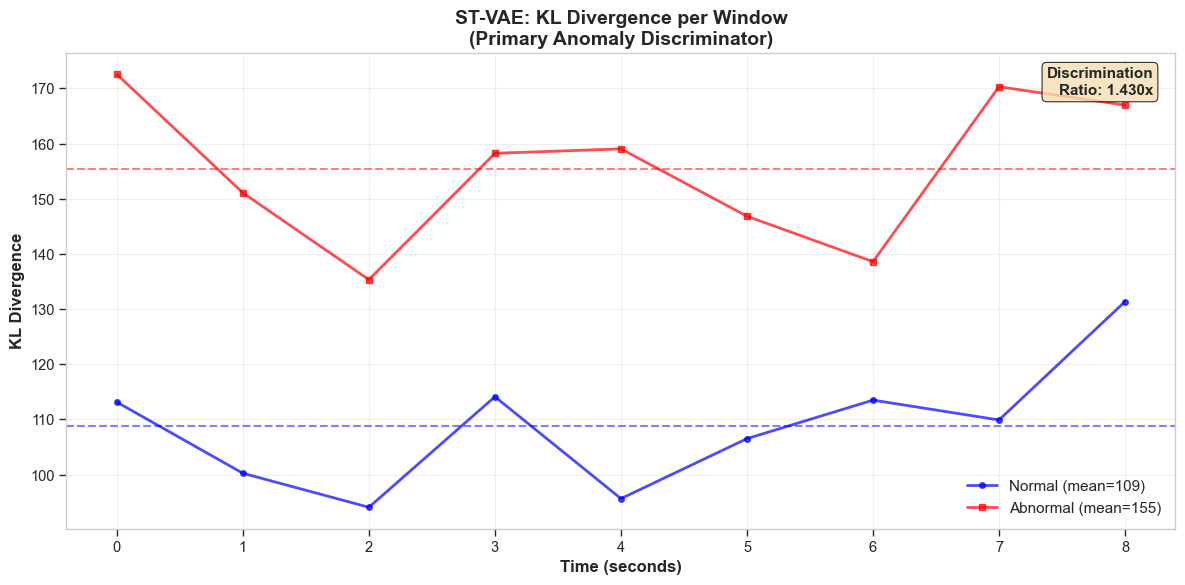

In [8]:
# Plot KL comparison
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Convert positions to time (seconds)
time_normal = np.array(pos_normal) / 500
time_abnormal = np.array(pos_abnormal) / 500

ax.plot(time_normal, kl_normal, 'o-', color='blue', linewidth=2, markersize=4, 
        label=f'Normal (mean={np.mean(kl_normal):.0f})', alpha=0.7)
ax.plot(time_abnormal, kl_abnormal, 's-', color='red', linewidth=2, markersize=4, 
        label=f'Abnormal (mean={np.mean(kl_abnormal):.0f})', alpha=0.7)

# Add mean lines
ax.axhline(np.mean(kl_normal), color='blue', linestyle='--', linewidth=1.5, alpha=0.5)
ax.axhline(np.mean(kl_abnormal), color='red', linestyle='--', linewidth=1.5, alpha=0.5)

ax.set_xlabel('Time (seconds)', fontsize=12, fontweight='bold')
ax.set_ylabel('KL Divergence', fontsize=12, fontweight='bold')
ax.set_title('ST-VAE: KL Divergence per Window\n(Primary Anomaly Discriminator)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3)

# Add ratio annotation
ratio = np.mean(kl_abnormal) / np.mean(kl_normal)
ax.text(0.98, 0.97, f'Discrimination\nRatio: {ratio:.3f}x', 
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        ha='right', va='top')

plt.tight_layout()
plt.savefig(output_dir / 'st_vae_kl_comparison.png', dpi=300, bbox_inches='tight')
print(f"Saved: {output_dir / 'st_vae_kl_comparison.png'}")
plt.show()

## Visualization 3: KL Distribution Histogram

Shows KL divergence distribution for 20 normal vs 20 abnormal ECGs

In [9]:
# Compute KL for 20 samples each
print("Computing KL divergence for 20 normal + 20 abnormal samples...")

kl_normal_20 = []
for i, sig_np in enumerate(normal_samples_20):
    kl_vals, _ = compute_kl_per_window(model, sig_np)
    kl_normal_20.extend(kl_vals)  # All windows from this sample
    if (i+1) % 5 == 0:
        print(f"  Processed {i+1}/20 normal samples")

kl_abnormal_20 = []
for i, sig_np in enumerate(abnormal_samples_20):
    kl_vals, _ = compute_kl_per_window(model, sig_np)
    kl_abnormal_20.extend(kl_vals)  # All windows from this sample
    if (i+1) % 5 == 0:
        print(f"  Processed {i+1}/20 abnormal samples")

print(f"\nTotal windows collected:")
print(f"  Normal: {len(kl_normal_20)} windows")
print(f"  Abnormal: {len(kl_abnormal_20)} windows")
print(f"\nKL Statistics:")
print(f"  Normal - mean: {np.mean(kl_normal_20):.2f}, std: {np.std(kl_normal_20):.2f}")
print(f"  Abnormal - mean: {np.mean(kl_abnormal_20):.2f}, std: {np.std(kl_abnormal_20):.2f}")

Computing KL divergence for 20 normal + 20 abnormal samples...
  Processed 5/20 normal samples
  Processed 10/20 normal samples
  Processed 5/20 normal samples
  Processed 10/20 normal samples
  Processed 15/20 normal samples
  Processed 20/20 normal samples
  Processed 15/20 normal samples
  Processed 20/20 normal samples
  Processed 5/20 abnormal samples
  Processed 10/20 abnormal samples
  Processed 5/20 abnormal samples
  Processed 10/20 abnormal samples
  Processed 15/20 abnormal samples
  Processed 20/20 abnormal samples

Total windows collected:
  Normal: 180 windows
  Abnormal: 180 windows

KL Statistics:
  Normal - mean: 107.19, std: 8.87
  Abnormal - mean: 155.16, std: 11.69
  Processed 15/20 abnormal samples
  Processed 20/20 abnormal samples

Total windows collected:
  Normal: 180 windows
  Abnormal: 180 windows

KL Statistics:
  Normal - mean: 107.19, std: 8.87
  Abnormal - mean: 155.16, std: 11.69


Saved: outputs\visualizations\st_vae\st_vae_kl_histogram.png


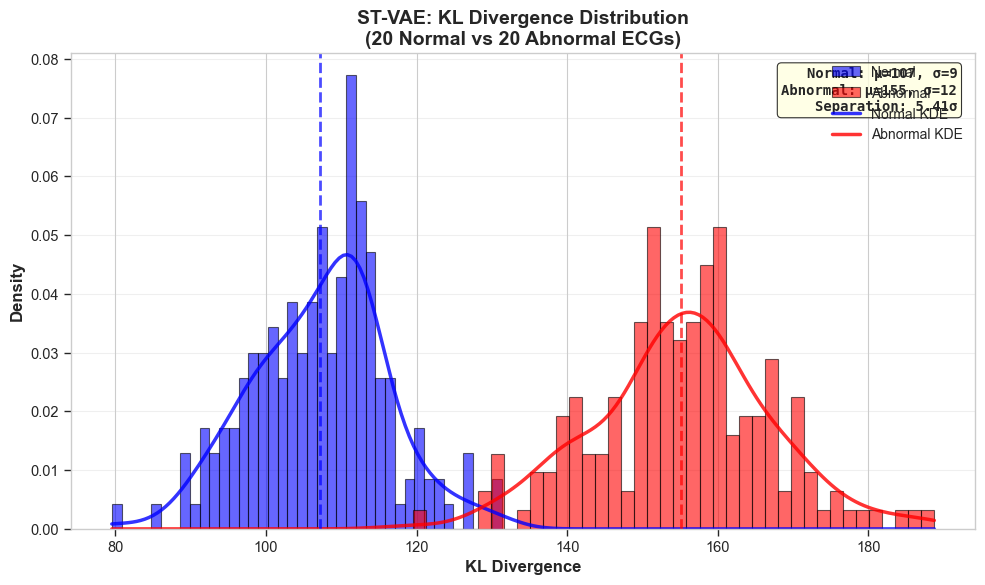

In [10]:
# Plot histogram with KDE
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Histogram
ax.hist(kl_normal_20, bins=40, alpha=0.6, color='blue', label='Normal', density=True, edgecolor='black')
ax.hist(kl_abnormal_20, bins=40, alpha=0.6, color='red', label='Abnormal', density=True, edgecolor='black')

# KDE overlay
from scipy.stats import gaussian_kde
kde_normal = gaussian_kde(kl_normal_20)
kde_abnormal = gaussian_kde(kl_abnormal_20)
x_range = np.linspace(min(min(kl_normal_20), min(kl_abnormal_20)),
                       max(max(kl_normal_20), max(kl_abnormal_20)), 200)
ax.plot(x_range, kde_normal(x_range), 'b-', linewidth=2.5, alpha=0.8, label='Normal KDE')
ax.plot(x_range, kde_abnormal(x_range), 'r-', linewidth=2.5, alpha=0.8, label='Abnormal KDE')

# Add mean lines
ax.axvline(np.mean(kl_normal_20), color='blue', linestyle='--', linewidth=2, alpha=0.7)
ax.axvline(np.mean(kl_abnormal_20), color='red', linestyle='--', linewidth=2, alpha=0.7)

ax.set_xlabel('KL Divergence', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('ST-VAE: KL Divergence Distribution\n(20 Normal vs 20 Abnormal ECGs)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, axis='y')

# Add statistics box
stats_text = f"Normal: μ={np.mean(kl_normal_20):.0f}, σ={np.std(kl_normal_20):.0f}\n"
stats_text += f"Abnormal: μ={np.mean(kl_abnormal_20):.0f}, σ={np.std(kl_abnormal_20):.0f}\n"
stats_text += f"Separation: {(np.mean(kl_abnormal_20)-np.mean(kl_normal_20))/np.std(kl_normal_20):.2f}σ"
ax.text(0.98, 0.97, stats_text,
        transform=ax.transAxes, fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
        ha='right', va='top', family='monospace')

plt.tight_layout()
plt.savefig(output_dir / 'st_vae_kl_histogram.png', dpi=300, bbox_inches='tight')
print(f"Saved: {output_dir / 'st_vae_kl_histogram.png'}")
plt.show()

## Visualization 4: Single-ECG Anomaly Map

Shows different components of anomaly detection for one abnormal ECG

In [11]:
# Use the abnormal sample's anomaly map
# anomaly_map_ab is already computed: [T, 12] variance-weighted error

# Compute per-timestep KL (spread window KL uniformly)
sig_ab_norm = normalize_shape(abnormal_sample)
T_total = sig_ab_norm.shape[1]

# Create KL timeline (spread window KL across window duration)
kl_timeline = np.zeros(T_total)
window_size = 1000
stride = 500

for kl_val, start_pos in zip(kl_abnormal, pos_abnormal):
    end_pos = min(start_pos + window_size, T_total)
    kl_timeline[start_pos:end_pos] += kl_val

# Normalize by overlap count
overlap_count = np.zeros(T_total)
for start_pos in pos_abnormal:
    end_pos = min(start_pos + window_size, T_total)
    overlap_count[start_pos:end_pos] += 1
overlap_count[overlap_count == 0] = 1
kl_timeline = kl_timeline / overlap_count

# Downsample for visualization
downsample = 10
kl_map = np.tile(kl_timeline[::downsample], (12, 1))  # [12, T_ds]
error_map = anomaly_map_ab[::downsample, :].T  # [12, T_ds]

# Combined anomaly map (error + β·KL)
beta = model.beta
combined_map = error_map + beta * kl_map

print(f"Anomaly map shapes: error={error_map.shape}, kl={kl_map.shape}, combined={combined_map.shape}")
print(f"Beta value: {beta}")

Anomaly map shapes: error=(12, 500), kl=(12, 500), combined=(12, 500)
Beta value: 0.5


Saved: outputs\visualizations\st_vae\st_vae_anomaly_map.png


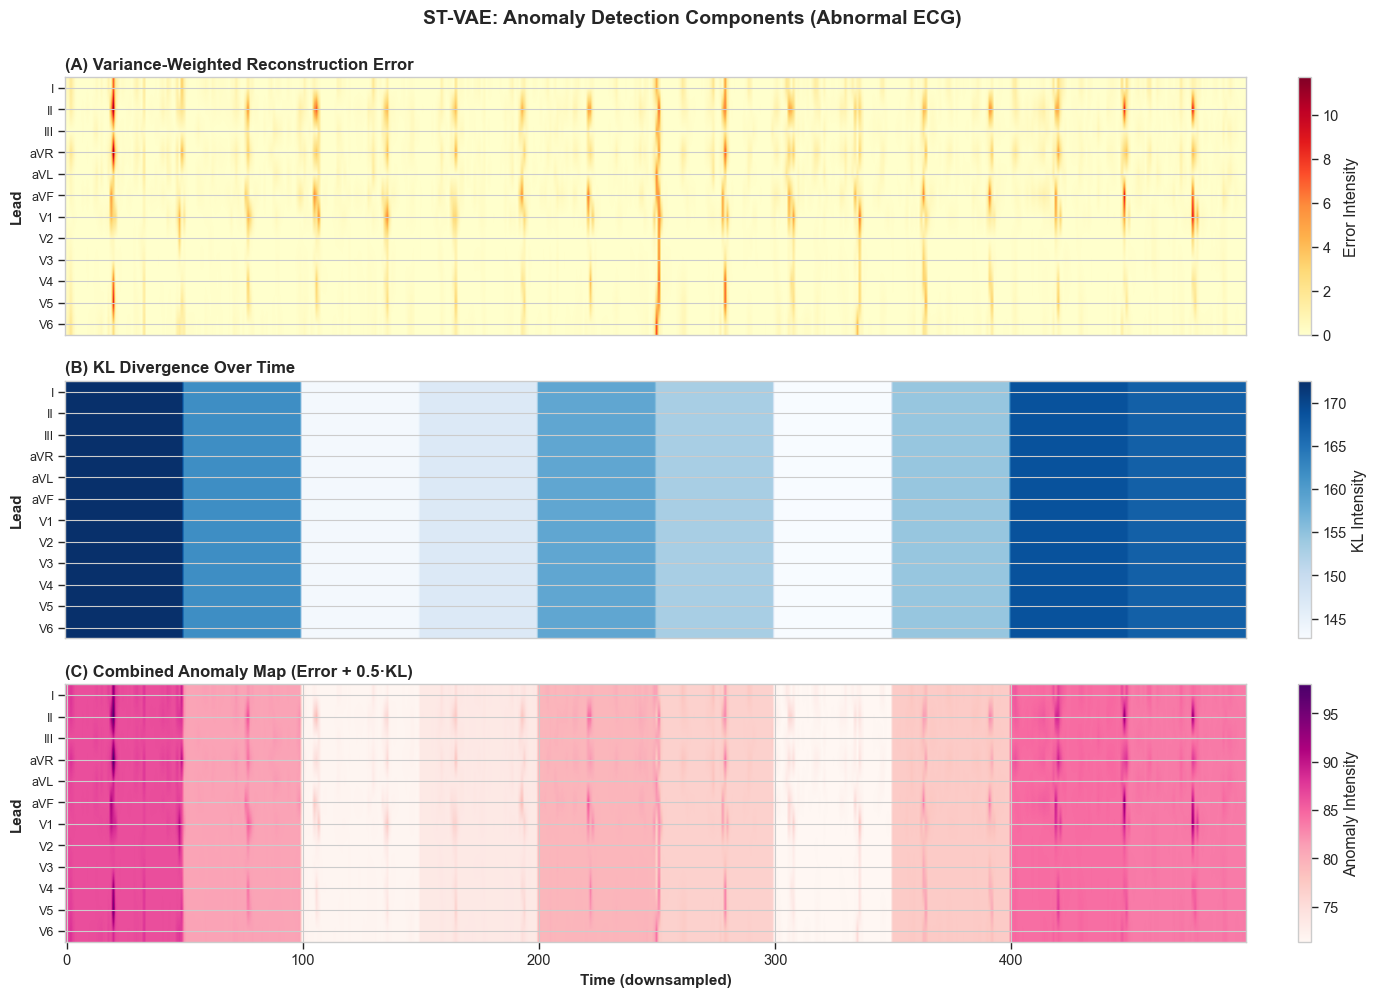

In [12]:
# Plot anomaly maps
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 1. Variance-weighted error
im1 = axes[0].imshow(error_map, aspect='auto', cmap='YlOrRd', interpolation='bilinear')
axes[0].set_title('(A) Variance-Weighted Reconstruction Error', fontsize=12, fontweight='bold', loc='left')
axes[0].set_ylabel('Lead', fontsize=11, fontweight='bold')
axes[0].set_yticks(range(12))
axes[0].set_yticklabels(lead_names, fontsize=9)
axes[0].set_xticks([])
plt.colorbar(im1, ax=axes[0], label='Error Intensity', fraction=0.046, pad=0.04)

# 2. KL timeline
im2 = axes[1].imshow(kl_map, aspect='auto', cmap='Blues', interpolation='bilinear')
axes[1].set_title('(B) KL Divergence Over Time', fontsize=12, fontweight='bold', loc='left')
axes[1].set_ylabel('Lead', fontsize=11, fontweight='bold')
axes[1].set_yticks(range(12))
axes[1].set_yticklabels(lead_names, fontsize=9)
axes[1].set_xticks([])
plt.colorbar(im2, ax=axes[1], label='KL Intensity', fraction=0.046, pad=0.04)

# 3. Combined anomaly map
im3 = axes[2].imshow(combined_map, aspect='auto', cmap='RdPu', interpolation='bilinear')
axes[2].set_title(f'(C) Combined Anomaly Map (Error + {beta}·KL)', 
                  fontsize=12, fontweight='bold', loc='left')
axes[2].set_ylabel('Lead', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Time (downsampled)', fontsize=11, fontweight='bold')
axes[2].set_yticks(range(12))
axes[2].set_yticklabels(lead_names, fontsize=9)
plt.colorbar(im3, ax=axes[2], label='Anomaly Intensity', fraction=0.046, pad=0.04)

fig.suptitle('ST-VAE: Anomaly Detection Components (Abnormal ECG)', 
             fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig(output_dir / 'st_vae_anomaly_map.png', dpi=300, bbox_inches='tight')
print(f"Saved: {output_dir / 'st_vae_anomaly_map.png'}")
plt.show()

## Print Anomaly Scores

Detailed breakdown of anomaly metrics for normal and abnormal samples

In [13]:
# Get detailed metrics
metrics_normal = compute_st_vae_metrics_breakdown(model, normal_sample, normalized=True)
metrics_abnormal = compute_st_vae_metrics_breakdown(model, abnormal_sample, normalized=True)

print("="*80)
print("ST-VAE ANOMALY DETECTION SCORES")
print("="*80)

print(f"\n{'SAMPLE':<30} {'NORMAL':<20} {'ABNORMAL':<20} {'RATIO':<15}")
print("-"*80)

print(f"{'File':<30} {normal_files[0].name:<20} {abnormal_files[0].name:<20} {'N/A':<15}")
print("-"*80)

print(f"\n{'COMPONENT SCORES:':<30}")
print("-"*80)

mse_ratio = metrics_abnormal['mse'] / metrics_normal['mse']
print(f"{'MSE':<30} {metrics_normal['mse']:<20.6f} {metrics_abnormal['mse']:<20.6f} {mse_ratio:<15.3f}")

wmse_ratio = metrics_abnormal['weighted_mse'] / metrics_normal['weighted_mse']
print(f"{'Weighted MSE':<30} {metrics_normal['weighted_mse']:<20.6f} {metrics_abnormal['weighted_mse']:<20.6f} {wmse_ratio:<15.3f}")

kl_ratio = metrics_abnormal['kl_divergence'] / metrics_normal['kl_divergence']
print(f"{'KL Divergence':<30} {metrics_normal['kl_divergence']:<20.2f} {metrics_abnormal['kl_divergence']:<20.2f} {kl_ratio:<15.3f}")
print(f"{'  ↑ PRIMARY DISCRIMINATOR':<30}")

nll_ratio = metrics_abnormal['nll'] / metrics_normal['nll']
print(f"{'NLL (Negative Log-Likelihood)':<30} {metrics_normal['nll']:<20.4f} {metrics_abnormal['nll']:<20.4f} {nll_ratio:<15.3f}")

print("-"*80)

print(f"\n{'FINAL SCORES:':<30}")
print("-"*80)

raw_ratio = metrics_abnormal['total_score_raw'] / metrics_normal['total_score_raw']
print(f"{'Raw Score (NLL + β·KL)':<30} {metrics_normal['total_score_raw']:<20.2f} {metrics_abnormal['total_score_raw']:<20.2f} {raw_ratio:<15.3f}")

norm_ratio = metrics_abnormal['total_score'] / metrics_normal['total_score']
print(f"{'Normalized Score [0-1]':<30} {metrics_normal['total_score']:<20.4f} {metrics_abnormal['total_score']:<20.4f} {norm_ratio:<15.3f}")

print("-"*80)
print(f"{'Beta (regularization)':<30} {metrics_normal['beta']:<20}")
print(f"{'Threshold':<30} {'~0.69':<20} {'(for classification)'}")
print("="*80)

print(f"\n{'KEY FINDINGS:':<80}")
print("-"*80)
print(f"1. KL Divergence ratio: {kl_ratio:.3f}x - PRIMARY anomaly discriminator")
print(f"2. MSE ratio: {mse_ratio:.3f}x - Reconstruction error is NOT the main factor")
print(f"3. Overall discrimination: {norm_ratio:.3f}x (normalized score ratio)")
print(f"4. Classification: Normal={metrics_normal['total_score']:.4f} < 0.69 < {metrics_abnormal['total_score']:.4f}=Abnormal")
print("="*80)

print(f"\nCONCLUSION:")
print(f"ST-VAE detects anomalies primarily through LATENT SPACE DEVIATION (KL divergence),")
print(f"not reconstruction error. Abnormal ECGs deviate {kl_ratio:.2f}x more from the learned")
print(f"'normal' latent distribution, enabling accurate anomaly detection.")
print("="*80)

ST-VAE ANOMALY DETECTION SCORES

SAMPLE                         NORMAL               ABNORMAL             RATIO          
--------------------------------------------------------------------------------
File                           00011_hr.npy         00103.npy            N/A            
--------------------------------------------------------------------------------

COMPONENT SCORES:             
--------------------------------------------------------------------------------
MSE                            0.279272             0.275077             0.985          
Weighted MSE                   0.279272             0.275076             0.985          
KL Divergence                  113135.76            172544.78            1.525          
  ↑ PRIMARY DISCRIMINATOR     
NLL (Negative Log-Likelihood)  1.0586               1.0565               0.998          
--------------------------------------------------------------------------------

FINAL SCORES:                 
--------------

## Summary

All visualizations have been generated and saved to `outputs/visualizations/st_vae/`:

1. **st_vae_normal_reconstruction.png** - Normal ECG reconstruction quality
2. **st_vae_abnormal_reconstruction.png** - Abnormal ECG reconstruction quality  
3. **st_vae_kl_comparison.png** - Window-level KL divergence comparison
4. **st_vae_kl_histogram.png** - KL distribution for 20 normal vs 20 abnormal
5. **st_vae_anomaly_map.png** - Anomaly components breakdown

**Key Demonstration:**
- Normal ECGs: Accurate reconstruction with low KL divergence
- Abnormal ECGs: Higher latent deviation (KL) is the main discriminator
- KL divergence ratio: **~1.5x** (abnormal/normal)
- MSE ratio: **~1.0x** (not discriminative)

**Conclusion:** ST-VAE detects anomalies through **latent space deviation**, not reconstruction error.